In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import numpy as np
from tqdm import tqdm
import matplotlib
import pickle as pi
from funcs_for_kappa_BHZ import localgap_sys
from funcs_for_kappa_3D import localgap_sys_3D

import matplotlib.pyplot as plt
import cmasher as csh
import matplotlib.gridspec as gridspec

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

In [4]:
# model parameters
system_size = 10
A = 1.0
B = 1.0
onsite_disorder = 0
bond_power = 1.1
Delta = 2
# localizer parameters
E0 = 0.0
kappa = 1



# kappa vs E

In [5]:
kappa_values = np.linspace(0, 25, 50)
E_values = np.linspace(-2.5, 2.5, 50)

Delta_values = np.linspace(-2, 4, 50)
W_values = np.linspace(0, 15, 50)
# localgap_grid = np.zeros((len(kappa_values), len(E_values)))

# for i, kappa in tqdm(enumerate(kappa_values)):
#     for j, E0 in enumerate(E_values):
#         localgap_grid[i, j] = localgap_sys(
#             system_size=system_size,
#             Delta=Delta,
#             A=A,
#             B=B,
#             bond_power=bond_power,
#             onsite_disorder=onsite_disorder,
#             E0=E0,
#             kappa=kappa
#         )
    
        
        

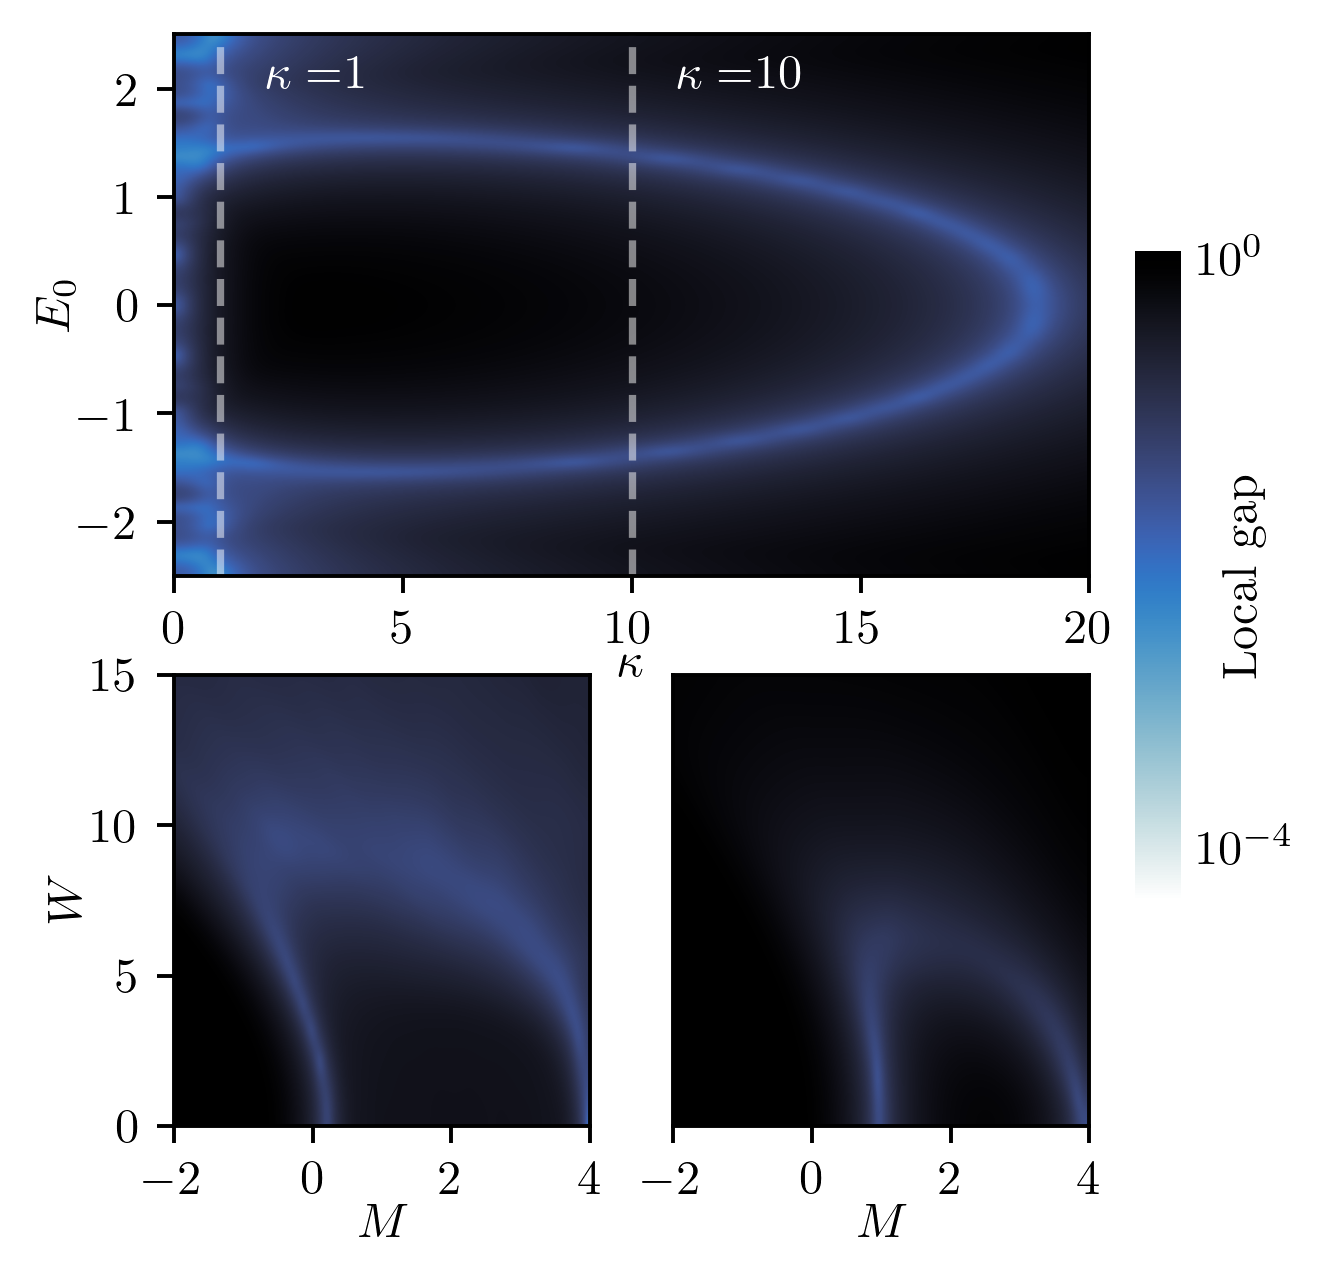

In [7]:
localgap_grid = pi.load(open("data/localgap_kappa_E_grid.pkl", "rb"))
avg_locgap = [
    pi.load(open("data/kappa-1_locgap_Delta_W_grid.pkl", "rb")),
    pi.load(open("data/kappa-10_locgap_Delta_W_grid.pkl", "rb"))
]

fig = plt.figure(figsize=(aps_halfwidth, aps_halfwidth*1.2), dpi=350)
gs = gridspec.GridSpec(
    2, 2,
    height_ratios=[1.2, 1],
    width_ratios=[1, 1], 
    )

ax_top = fig.add_subplot(gs[0, :2])
ax_bl = fig.add_subplot(gs[1, 0])
ax_br = fig.add_subplot(gs[1, 1])


im = ax_top.imshow(
    localgap_grid.T,
    extent=(kappa_values[0], kappa_values[-1], E_values[0], E_values[-1]),
    origin="lower",
    aspect="auto",
    cmap=csh.arctic_r,
    interpolation='bicubic',
    norm='log',
    rasterized=True,
)


for x in [1,10]:
    ax_top.axvline(x=x, color='white', linestyle='--', alpha=0.5)
    ax_top.text(x+1, E_values[-1]-0.5, r'$\kappa=$'+str(x), color='white')

ax_top.set_xlim(0,20)

ax_top.set_xlabel(r'$\kappa$', labelpad=-2)
ax_top.set_ylabel(r'$E_0$', labelpad=0)
# plt.savefig("localgap_kappa_grid.png", bbox_inches='tight')



for i, axes in enumerate([ax_bl, ax_br]):
    axes.imshow(
        avg_locgap[i].T,
        extent=(Delta_values[0], Delta_values[-1], W_values[0], W_values[-1]),
        origin="lower",
        aspect="auto",
        cmap=csh.arctic_r,
        interpolation='bicubic',
        norm='log',
        vmin=10**np.round(np.min(np.log10(localgap_grid[:,:].T))),
        vmax=10**np.floor(np.max(np.log10(localgap_grid[:,:].T))),
        rasterized=True,
    )
    axes.set_xticks([-2, 0, 2, 4])
    axes.set_xlabel(r'$M$', labelpad=0)
    
ax_bl.set_ylabel(r'$W$', labelpad=0)
ax_br.set_yticks([])


ax_cbar = ax_top.inset_axes([1.05, -0.6, 0.05, 1.2])
cbar = fig.colorbar(
    im,
    cax=ax_cbar,
    orientation='vertical',
    fraction=1,
    norm='log',
    # label='Local gap',
    )
cbar.set_label('Local gap', labelpad=-15)
cbar.outline.set_visible(False)
cbar.ax.minorticks_off()     
cbar.ax.tick_params(length=0)      
cbar.set_ticks([10**np.round(np.min(np.log10(localgap_grid[:,:].T))), 10**np.floor(np.max(np.log10(localgap_grid[:,:].T)))])


ax_cbar.tick_params(length=0)
ax_cbar.set_frame_on(False)
ax_cbar.set_rasterized(True)
# cbar.outline.set_visible(False)

label = ['a)', 'b)', 'c)']
# for axes in [ax_top, ax_bl, ax_br]:
#     axes.text(label.pop(0), transform=axes.transAxes, xy=(0.05, 0.9), color='white', y=0.9, s=axes.texts[0].get_text(), fontsize=12)

In [ ]:
fig.savefig("localgap_kappa_grid.pdf", bbox_inches='tight', dpi=350)


# 3D

In [ ]:
# lattice params
system_size = 10

# sys params
A = 1
bond_lengthscale = 1 / system_size
bond_power = 1 / system_size
bond_distance = 1.3 / system_size
# localizer params
kappa = 2
E0 = 0
# onsite disorder
onsite_disorder = 0
seed = 0

# structural disorder params
sigma = 0
kappa_shift = 0
beta = 1
resolution=10

# computational params
num_realizations = 1
MJ = 1




In [26]:
import os, re
from pathlib import Path
folder = Path.cwd() / "3D_kappa_2" 
dic = []

def extract_from_folder(filename):
    match = re.search(r'_seed_([-+]?[0-9]*\.?[0-9]+)', filename)
    if match:
        return float(match.group(1))
    return float('inf')

print(sorted(os.listdir(folder), key=extract_from_folder))

for file in sorted(os.listdir(folder), key=extract_from_folder):
    dic.append(pi.load(open(os.path.join(folder, file), 'rb')))

['locgap_grid_3D_M_W_seed_3.pkl', 'locgap_grid_3D_M_W_seed_4.pkl', 'locgap_grid_3D_M_W_seed_6.pkl', 'locgap_grid_3D_M_W_seed_7.pkl', 'locgap_grid_3D_M_W_seed_9.pkl', 'locgap_grid_3D_M_W_seed_11.pkl', 'locgap_grid_3D_M_W_seed_14.pkl', 'locgap_grid_3D_M_W_seed_22.pkl', 'locgap_grid_3D_M_W_seed_23.pkl', 'locgap_grid_3D_M_W_seed_24.pkl', 'locgap_grid_3D_M_W_seed_27.pkl', 'locgap_grid_3D_M_W_seed_28.pkl', 'locgap_grid_3D_M_W_seed_29.pkl', 'locgap_grid_3D_M_W_seed_30.pkl', 'locgap_grid_3D_M_W_seed_33.pkl', 'locgap_grid_3D_M_W_seed_34.pkl', 'locgap_grid_3D_M_W_seed_37.pkl', 'locgap_grid_3D_M_W_seed_38.pkl', 'locgap_grid_3D_M_W_seed_40.pkl', 'locgap_grid_3D_M_W_seed_42.pkl', 'locgap_grid_3D_M_W_seed_45.pkl']


In [31]:
grid = []

for lista in dic:
    grid_seed = np.array([lista[k] for k in lista.keys()])
    grid.append(grid_seed)
grid = np.array(grid)
grid = np.mean(grid, axis=0)

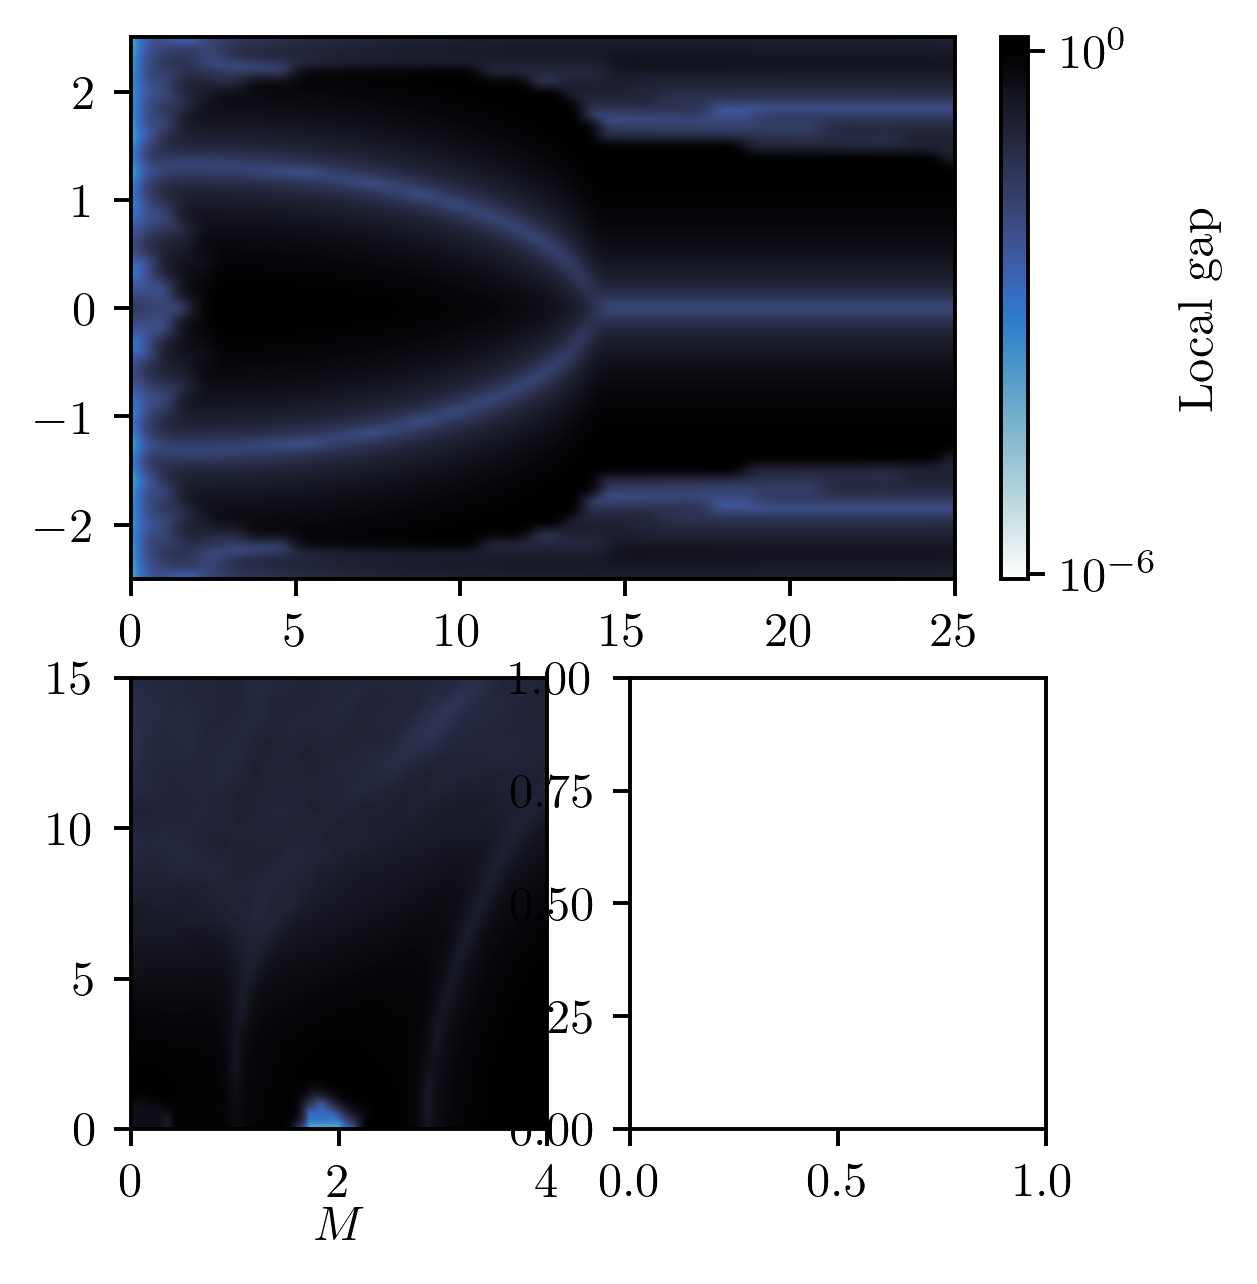

In [39]:
M_values = np.linspace(0, 4, 50)

localgap_grid = pi.load(open("data/3D_locgap_grid_kappa_E", "rb"))
# avg_locgap = [
#     pi.load(open("data/kappa-1_locgap_Delta_W_grid.pkl", "rb")),
#     pi.load(open("data/kappa-10_locgap_Delta_W_grid.pkl", "rb"))
# ]
# localgap_grid = np.array([localgap_grid[k] for k in localgap_grid.keys()])
fig = plt.figure(figsize=(aps_halfwidth, aps_halfwidth*1.2), dpi=350)
gs = gridspec.GridSpec(
    2, 2,
    height_ratios=[1.2, 1],
    width_ratios=[1, 1], 
    )

ax_top = fig.add_subplot(gs[0, :2])
ax_bl = fig.add_subplot(gs[1, 0])
ax_br = fig.add_subplot(gs[1, 1])


im = ax_top.imshow(
    localgap_grid.T,
    extent=(kappa_values[0], kappa_values[-1], E_values[0], E_values[-1]),
    origin="lower",
    aspect="auto",
    cmap=csh.arctic_r,
    interpolation='bicubic',
    norm='log',
    rasterized=True,
)


# colorbar

# for x in [1,10]:
#     ax_top.axvline(x=x, color='white', linestyle='--', alpha=0.5)
#     ax_top.text(x+1, E_values[-1]-0.5, r'$\kappa=$'+str(x), color='white')

# ax_top.set_xlim(0,20)

# ax_top.set_xlabel(r'$\kappa$', labelpad=-2)
# ax_top.set_ylabel(r'$E_0$', labelpad=0)
# # plt.savefig("localgap_kappa_grid.png", bbox_inches='tight')


axes = ax_bl
# for i, axes in enumerate([ax_bl, ax_br]):
im = axes.imshow(
    grid.T,
    extent=(M_values[0], M_values[-1], W_values[0], W_values[-1]),
    origin="lower",
    aspect="auto",
    cmap=csh.arctic_r,
    interpolation='bicubic',
    norm='log',
    rasterized=True,
)
# axes.set_xticks([-2, 0, 2, 4])
axes.set_xlabel(r'$M$', labelpad=0)
fig.colorbar(
    im,
    ax=ax_top,
    orientation='vertical',
    fraction=0.05,
    norm='log',
    label='Local gap',
    ticks=[10**np.round(np.min(np.log10(grid[:,:].T))), 10**np.floor(np.max(np.log10(grid[:,:].T)))], )

# ax_bl.set_ylabel(r'$W$', labelpad=0)
# ax_br.set_yticks([])


# ax_cbar = ax_top.inset_axes([1.05, -0.6, 0.05, 1.2])
# cbar = fig.colorbar(
#     im,
#     cax=ax_cbar,
#     orientation='vertical',
#     fraction=1,
#     norm='log',
#     # label='Local gap',
#     )
# cbar.set_label('Local gap', labelpad=-15)
# cbar.outline.set_visible(False)
# cbar.ax.minorticks_off()     
# cbar.ax.tick_params(length=0)      
# cbar.set_ticks([10**np.round(np.min(np.log10(localgap_grid[:,:].T))), 10**np.floor(np.max(np.log10(localgap_grid[:,:].T)))])


# ax_cbar.tick_params(length=0)
# ax_cbar.set_frame_on(False)
# ax_cbar.set_rasterized(True)
# # cbar.outline.set_visible(False)

# label = ['a)', 'b)', 'c)']
# # for axes in [ax_top, ax_bl, ax_br]:
# #     axes.text(label.pop(0), transform=axes.transAxes, xy=(0.05, 0.9), color='white', y=0.9, s=axes.texts[0].get_text(), fontsize=12)

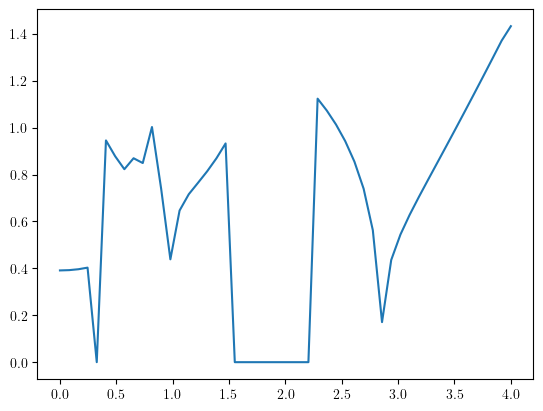

In [42]:
check_x = dic[0].keys()
check_y = [dic[0][k][0] for k in dic[0].keys()]

plt.figure()
plt.plot(check_x, check_y)